# Case Study 11 — Logistics Sustainability Analysis

**Group 11**

- Ali Güler
- Kaya Louis Dedeoglu
- Kian Keighobadi
- Moritz Sebastian Arminius Schmidt
- Ashwin Ajith Kumar

**Case:** OEM1 supply-chain logistics routes for vehicles produced in **2015**, restricted to the **engine, gearshift and their installed individual parts**.

## Contents 

1. Introduction
2. Project Setup
3. Importing and Exploring the Data
4. Data Preparation and Route Integration
5. Creating Final Dataset
6. Evaluation and Results

# 1. Introduction

## 1.1 Objective

The task is to reconstruct the supply chain of vehicles produced by OEM1 in 2015 and determine the total logistics distance travelled before the vehicles reach their customers in order to assess the manufacturer's sustainability. The analysis focuses on the engine and gearshift components as well as the corresponding parts installed in these components.

For each relevant vehicle, the logistics routes from the single-part suppliers to the component suppliers, from the component suppliers to the OEM1 production plant, and from the production plant to the responsible distribution center are reconstructed. At the distribution center, the vehicle handover to the customer is assumed to take place. This assumption is made due to the sustainability objective of focusing on logistics stages that can be influenced by the manufacturer. The manufacturer has no influence on the distance between a customer's location and the responsible distribution center. Furthermore, the registration location does not necessarily correspond to the actual customer location, making an estimation of the final delivery route unreliable. Therefore, no additional transportation from the distribution center to the customer location is considered.

Furthermore, it is assumed that each distribution center is located in the state capital corresponding to the customer's state of registration.

# 2. Project Setup

The original folders are stored below `data/IDA SoSe26 - Data`. Needed modules are imported and needed functions are defined in this section.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def read_matches(path, usecols, column, values, sep=";", chunksize=250_000):
    """Read only rows whose key occurs in values, without changing the file."""
    matches = []
    for chunk in pd.read_csv(
        path,
        sep=sep,
        usecols=usecols,
        dtype="string",
        chunksize=chunksize,
    ):
        selected = chunk.loc[chunk[column].isin(values)].copy()
        if not selected.empty:
            matches.append(selected)
    return (
        pd.concat(matches, ignore_index=True)
        if matches
        else pd.DataFrame(columns=usecols)
    )


def read_matches_suffix_resolve(
    path,
    base_columns,
    values,
    suffixes,
    sep=",",
    chunksize=250_000,
):
    """Read relevant component records and resolve suffixed duplicate columns."""

    id_column = base_columns[0]

    usecols = [
        f"{column}{suffix}"
        for suffix in suffixes
        for column in base_columns
    ]

    clean_chunks = []

    for chunk in pd.read_csv(
        path,
        usecols=usecols,
        dtype="string",
        sep=sep,
        chunksize=chunksize,
    ):
        for suffix in suffixes:
            id_col = f"{id_column}{suffix}"

            mask = chunk[id_col].isin(values)

            if not mask.any():
                continue

            selected = chunk.loc[
                mask,
                [f"{column}{suffix}" for column in base_columns]
            ].copy()

            selected.columns = base_columns

            clean_chunks.append(selected)

    if not clean_chunks:
        return pd.DataFrame(columns=base_columns)

    return pd.concat(clean_chunks, ignore_index=True)

def first_line_preview(path, sep=",", encoding="utf-8"):
    """Return the first data row of a delimited text file."""
    return pd.read_csv(path, sep=sep, encoding=encoding, nrows=1)

def explore(dfs, df_names, id_column):
    """Return a exploration dataframe"""
    return pd.DataFrame(
        {
            "Missing values": [
                df.isna().sum().sum()
                for df in dfs
            ],
            "Duplicated ID": [
                df[id_column].duplicated().sum()
                for df in dfs
            ],
            "Duplicated rows": [
                df.duplicated().sum()
                for df in dfs
            ],
        },
        index= df_names,
    )



def explore_component(component_dfs, component_names, id_column):
    """Return a exploration dataframe for the components"""
    return pd.DataFrame(
        {
            "Missing values": [
                df.isna().sum().sum()
                for df in component_dfs
            ],
            "Duplicated component ID": [
                df[id_column].duplicated().sum()
                for df in component_dfs
            ],
            "Duplicated rows": [
                df.duplicated().sum()
                for df in component_dfs
            ],
            "Producers": [
                df["Herstellernummer"].unique()
                for df in component_dfs
            ],
            "Plants": [
                df["Werksnummer"].unique()
                for df in component_dfs
            ],
        },
        index=component_names,
    )


def haversine(lat1, lon1, lat2, lon2):
    """Calculate and return the Haverine Distance"""
    R = 6371  # radius of planet earth in km

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2)**2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# 3. Importing and Exploring the Data

To ensure a clean and structured analysis, the required data is imported and explored in this section. Irrelevant attributes and observations are excluded as early as possible to improve computational efficiency and reduce memory usage, while potentially usefull attributes are kept. The required datasets are identified based on the objective of the analysis, and the relevance of each dataset is explained. This section does not yet combine the datasets but only ensures space efficiency by relating previous findings.

Data cleaning is only partially done in this section. Missing or duplicated values are cleaned. Datatypes and formatting are later considered in the Data preparation and integration section.

## 3.1 Vehicle Datasets

### 3.1.1 Importing

First, the vehicle datasets are considered, as the task imposes the strongest restrictions on the vehicle data. Since only OEM1 vehicles produced in 2015 are relevant, the OEM1 Typ11 and Typ12 vehicle datasets are imported and filtered by production year. The `X1` column can be omitted because it is an index column with no valuable information. Furthermore, information on whether a vehicle is marked as Fehlerhaft (defective) is not relevant to the objective of this analysis. Therefore, the corresponding defect-related columns are excluded as well.

In [2]:
first_line_preview("data/IDA SoSe26 - Data/Fahrzeug/Fahrzeuge_OEM1_Typ11.csv")

,Unnamed: 0,X1,ID_Fahrzeug,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,1,1,11-1-11-1,2008-11-18,1,11,0,NaN,0


In [3]:
first_line_preview("data/IDA SoSe26 - Data/Fahrzeug/Fahrzeuge_OEM1_Typ12.csv", sep = ";")

,Unnamed: 0,X1,ID_Fahrzeug,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,1,1,12-1-12-1,2008-11-19,1,12,0,NaN,0


In [4]:
Typ11_chunks_2015 = []

for chunk in pd.read_csv(
    "data/IDA SoSe26 - Data/Fahrzeug/Fahrzeuge_OEM1_Typ11.csv",
    usecols=["ID_Fahrzeug", "Produktionsdatum", "Herstellernummer", "Werksnummer"],
    parse_dates=["Produktionsdatum"],
    chunksize=100_000
):
    Typ11_chunks_2015.append(chunk[chunk["Produktionsdatum"].dt.year == 2015])

OEM1_Typ11 = pd.concat(Typ11_chunks_2015, ignore_index= True)
OEM1_Typ11.head()

,ID_Fahrzeug,Produktionsdatum,Herstellernummer,Werksnummer
0,11-1-12-600034,2015-01-01,1,12
1,11-1-12-600035,2015-01-01,1,12
2,11-1-12-600036,2015-01-01,1,12
3,11-1-12-600037,2015-01-01,1,12
4,11-1-12-600038,2015-01-01,1,12


In [5]:
Typ12_chunks_2015 = []

for chunk in pd.read_csv(
    "data/IDA SoSe26 - Data/Fahrzeug/Fahrzeuge_OEM1_Typ12.csv",
    usecols=["ID_Fahrzeug", "Produktionsdatum", "Herstellernummer", "Werksnummer"],
    sep = ";",
    parse_dates=["Produktionsdatum"],
    chunksize=100_000
):
    Typ12_chunks_2015.append(chunk[chunk["Produktionsdatum"].dt.year == 2015])

OEM1_Typ12 = pd.concat(Typ12_chunks_2015, ignore_index= True)
OEM1_Typ12.head()

,ID_Fahrzeug,Produktionsdatum,Herstellernummer,Werksnummer
0,12-1-12-311125,2015-01-01,1,12
1,12-1-12-311126,2015-01-01,1,12
2,12-1-12-311127,2015-01-01,1,12
3,12-1-12-311128,2015-01-01,1,12
4,12-1-12-311129,2015-01-01,1,12


### 3.1.2 Exploring

In [6]:
OEM1_Typ11.info()
print("-" * 100)
OEM1_Typ12.info()

<class 'pandas.DataFrame'>
RangeIndex: 247868 entries, 0 to 247867
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ID_Fahrzeug       247868 non-null  str           
 1   Produktionsdatum  247868 non-null  datetime64[us]
 2   Herstellernummer  247868 non-null  int64         
 3   Werksnummer       247868 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 10.9 MB
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 51385 entries, 0 to 51384
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID_Fahrzeug       51385 non-null  str           
 1   Produktionsdatum  51385 non-null  datetime64[us]
 2   Herstellernummer  51385 non-null  int64         
 3   Werksnummer       51385 non-null

In [7]:
overview_Typ11 = pd.DataFrame(
    {
        "Missing values": [OEM1_Typ11.isna().sum().sum(), OEM1_Typ12.isna().sum().sum()],
        "Duplicated IDs": [OEM1_Typ11["ID_Fahrzeug"].duplicated().sum(), OEM1_Typ12["ID_Fahrzeug"].duplicated().sum()],
        "Earliest prod. date": [OEM1_Typ11["Produktionsdatum"].agg("min"), OEM1_Typ12["Produktionsdatum"].agg("min")],
        "Latest prod. date" : [OEM1_Typ11["Produktionsdatum"].agg("max"), OEM1_Typ12["Produktionsdatum"].agg("max")],
    },
    index= ["OEM1_Typ11", "OEM1_Typ12"]
)
overview_Typ11

,Missing values,Duplicated IDs,Earliest prod. date,Latest prod. date
OEM1_Typ11,0,0,2015-01-01,2015-12-31
OEM1_Typ12,0,0,2015-01-01,2015-12-31


In [8]:
OEM1_Typ11["Herstellernummer"].unique()

array([1])

In [9]:
OEM1_Typ12["Herstellernummer"].unique()

array([1])

In [10]:
pd.DataFrame(OEM1_Typ11["Werksnummer"].value_counts())

,count
Werksnummer,
11,148775
12,99093


In [11]:
pd.DataFrame(OEM1_Typ12["Werksnummer"].value_counts())

,count
Werksnummer,
12,51385


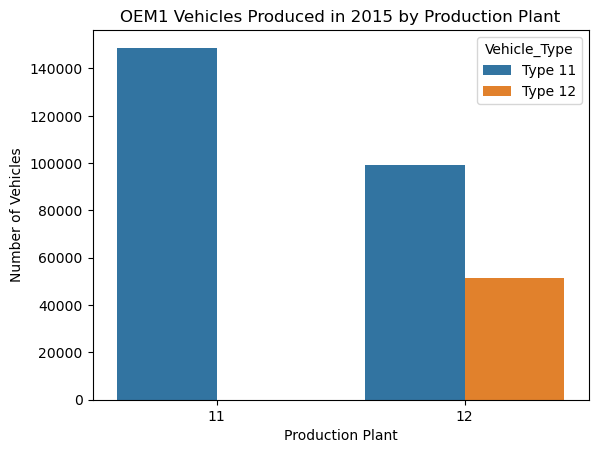

In [12]:
vehicle_plants = pd.concat([
    OEM1_Typ11.assign(Vehicle_Type="Type 11"),
    OEM1_Typ12.assign(Vehicle_Type="Type 12")
])

plant_counts = (
    vehicle_plants
    .groupby(["Werksnummer", "Vehicle_Type"])
    .size()
    .reset_index(name="Vehicle_Count")
)

sns.barplot(
    data=plant_counts,
    x="Werksnummer",
    y="Vehicle_Count",
    hue="Vehicle_Type"
)

plt.title("OEM1 Vehicles Produced in 2015 by Production Plant")
plt.xlabel("Production Plant")
plt.ylabel("Number of Vehicles")
plt.show()

The exploration shows that there are 247,868 unique Type 11 vehicles and 51,385 unique Type 12 vehicles produced in 2015, with no duplicated vehicle IDs. The filtering was successful, as all production dates fall within the year 2015. Furthermore, no missing values were identified in either dataset.

Both datasets contain a constant manufacturer number (`Herstellernummer`), since all vehicles are produced by `OEM1`. Notably, Type 11 vehicles produced in 2015 originate from both plants (`Werksnummer`) 11 and 12, whereas Type 12 vehicles are produced exclusively in plant 12.

## 3.2 Vehicle-Component Relational Tables

To access the components installed in the previously imported vehicles, the corresponding relational tables are now imported and briefly explored. Since the tasks explicitly focuses on OEM1 vehicles, the relevant relational tables are `Bestandteile_Fahrzeuge_OEM1_Typ11` and `Bestandteile_Fahrzeuge_OEM1_Typ12`. The task also explicitly focuses on the gearshift (`Schaltung`) and engine (`Motor`) components. Thefore, all other component types are excluded from the import and analysis.

In [13]:
first_line_preview("data/IDA SoSe26 - Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv", sep = ";")

,Unnamed: 0,ID_Karosserie,ID_Schaltung,ID_Sitze,ID_Motor,ID_Fahrzeug
0,1,K4-112-1121-3,K3SG1-105-1051-32,K2LE1-109-1091-2,K1BE1-101-1011-7,11-1-11-1


In [14]:
first_line_preview("data/IDA SoSe26 - Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ12.csv", sep = ";")

,Unnamed: 0,ID_Karosserie,ID_Schaltung,ID_Sitze,ID_Motor,ID_Fahrzeug
0,1,K5-112-1122-1,K3SG1-105-1051-4,K2ST1-109-1092-1,K1BE1-101-1011-90,12-1-12-1


In [15]:
vehicle_components_Typ11 = read_matches(path = "data/IDA SoSe26 - Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv",
                                        usecols = ["ID_Schaltung", "ID_Motor", "ID_Fahrzeug"],
                                        column = "ID_Fahrzeug",
                                        values = set(OEM1_Typ11["ID_Fahrzeug"]),
                                        )

In [16]:
vehicle_components_Typ11.head()

,ID_Schaltung,ID_Motor,ID_Fahrzeug
0,K3SG1-105-1051-581611,K1DI1-102-1021-179721,11-1-12-600034
1,K3SG1-105-1051-581655,K1BE1-101-1011-272075,11-1-12-600035
2,K3SG1-107-1071-871228,K1BE1-104-1041-543705,11-1-12-600036
3,K3SG1-107-1071-871039,K1DI1-103-1031-361823,11-1-12-600037
4,K3SG1-105-1051-581780,K1BE1-101-1011-271827,11-1-12-600038


In [17]:
vehicle_components_Typ12 = read_matches(path = "data/IDA SoSe26 - Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ12.csv",
                                        usecols = ["ID_Schaltung", "ID_Motor", "ID_Fahrzeug"],
                                        column = "ID_Fahrzeug",
                                        values = set(OEM1_Typ12["ID_Fahrzeug"]),
                                        )

In [18]:
vehicle_components_Typ12.head()

,ID_Schaltung,ID_Motor,ID_Fahrzeug
0,K3AG1-105-1051-106456,K1BE1-104-1041-543333,12-1-12-311125
1,K3SG1-105-1051-579466,K1BE1-101-1011-271726,12-1-12-311126
2,K3SG1-105-1051-579474,K1BE1-101-1011-271779,12-1-12-311127
3,K3SG1-105-1051-579534,K1BE1-104-1041-543463,12-1-12-311128
4,K3SG1-105-1051-579640,K1BE1-104-1041-543566,12-1-12-311129


In [19]:
vehicle_components_Typ11.info()
print("-" * 100)
vehicle_components_Typ12.info()

<class 'pandas.DataFrame'>
RangeIndex: 247868 entries, 0 to 247867
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   ID_Schaltung  247868 non-null  string
 1   ID_Motor      247868 non-null  string
 2   ID_Fahrzeug   247868 non-null  string
dtypes: string(3)
memory usage: 19.0 MB
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 51385 entries, 0 to 51384
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID_Schaltung  51385 non-null  string
 1   ID_Motor      51385 non-null  string
 2   ID_Fahrzeug   51385 non-null  string
dtypes: string(3)
memory usage: 3.9 MB


In [20]:
vehicle_componentes_overview = pd.DataFrame(
    {
        "Missing values": [vehicle_components_Typ11.isna().sum().sum(), vehicle_components_Typ12.isna().sum().sum()],
        "Duplicated rows" : [vehicle_components_Typ11.duplicated().sum(), vehicle_components_Typ12.duplicated().sum()],
        "Duplicated vehicle IDs" : [vehicle_components_Typ11["ID_Fahrzeug"].duplicated().sum(), vehicle_components_Typ12["ID_Fahrzeug"].duplicated().sum()],
        "Duplicated engine IDs" : [vehicle_components_Typ11["ID_Motor"].duplicated().sum(), vehicle_components_Typ12["ID_Motor"].duplicated().sum()],
        "Duplicated gearshift IDs" : [vehicle_components_Typ11["ID_Schaltung"].duplicated().sum(), vehicle_components_Typ12["ID_Schaltung"].duplicated().sum()]
    },

    index= ["Type 11", "Type 12"]
)

vehicle_componentes_overview

,Missing values,Duplicated rows,Duplicated vehicle IDs,Duplicated engine IDs,Duplicated gearshift IDs
Type 11,0,0,0,0,0
Type 12,0,0,0,0,0


In [21]:
missing_vehicles_typ11 = set(OEM1_Typ11["ID_Fahrzeug"]) - set(vehicle_components_Typ11["ID_Fahrzeug"])

missing_vehicles_typ12 = set(OEM1_Typ12["ID_Fahrzeug"]) - set(vehicle_components_Typ12["ID_Fahrzeug"])

len(missing_vehicles_typ11), len(missing_vehicles_typ12)

(0, 0)

The relational tables were imported according to the selection described above. A short exploration shows that there are no missing values and no duplicated vehicle or component IDs in the imported datasets. Additionally, it is confirmed that each vehicle ID in the vehicle datasets has exactly one corresponding entry in the relational tables.

## 3.3 Component Datasets

To access the relevant component information, the component datasets are imported based on the component IDs identified in the previous section. First, the required component datasets are identified. Afterwards, only records whose component IDs occur in the previously selected vehicle-component relations are imported. Although the manufacturer and plant numbers are encoded in the component IDs, the component datasets are used here to retrieve this information directly from the provided production data. Subsequently, for the single parts, these values are extracted from the IDs instead.

In [22]:
engine_types = pd.concat([
    vehicle_components_Typ11["ID_Motor"],
    vehicle_components_Typ12["ID_Motor"]
]).str.split("-").str[0].unique()

gearshift_types = pd.concat([
    vehicle_components_Typ11["ID_Schaltung"],
    vehicle_components_Typ12["ID_Schaltung"]
]).str.split("-").str[0].unique()

print(f"Engine types: {engine_types}")
print(f"Gearshit types: {gearshift_types}")

Engine types: ['K1DI1' 'K1BE1']
Gearshit types: ['K3SG1' 'K3AG1']


The only engine and gearshift types installed in OEM1 vehicles produced in 2015 are the engines `K1DI1` and `K1BE1` and the gearshifts `K3SG1` and `K3AG1`. Therefore, only the corresponding component datasets are imported.

### 3.3.1 Importing Engine Datasets

#### K1DI1 Engine

In [23]:
first_line_preview("data/IDA SoSe26 - Data/Komponente/Komponente_K1DI1.csv")

,Unnamed: 0,X1,ID_Motor.x,Produktionsdatum.x,Herstellernummer.x,Werksnummer.x,Fehlerhaft.x,Fehlerhaft_Datum.x,Fehlerhaft_Fahrleistung.x,ID_Motor.y,...,Fehlerhaft.y,Fehlerhaft_Datum.y,Fehlerhaft_Fahrleistung.y,ID_Motor,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,1,1,K1DI1-101-1041-90,2008-11-13,101,1011,0,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As previously mentioned, `X1` has no valuable information, while all columns related to defectiveness are irrelevant to the objective of this analysis. Furthermore, the dataset contains multiple versions of the same variables with suffixes such as `.x` and `.y`, indicating unresolved duplicated columns from a previous merge. This structure requires further investigation before the relevant component information can be imported into a clean and consistent dataset.

To keep the import process concise and computationally efficient, the unresolved duplicated columns are handled during import while retaining only records with relevant engine IDs.

In [24]:
engine_values = set(pd.concat([
    vehicle_components_Typ11["ID_Motor"],
    vehicle_components_Typ12["ID_Motor"]
]))


engine_k1di1 = read_matches_suffix_resolve(
    path="data/IDA SoSe26 - Data/Komponente/Komponente_K1DI1.csv",
    base_columns= ["ID_Motor","Herstellernummer", "Werksnummer"],
    values=engine_values,
    suffixes=[".x", ".y", ""],
)

In [25]:
engine_k1di1.head()

,ID_Motor,Herstellernummer,Werksnummer
0,K1DI1-101-1041-361289,101,1011
1,K1DI1-101-1041-361353,101,1011
2,K1DI1-101-1041-361378,101,1011
3,K1DI1-101-1041-361380,101,1011
4,K1DI1-101-1041-361469,101,1011


A quick confirmation shows that all expected `K1DI1` IDs were found.  

In [26]:
expected_k1di1 = {
    engine_id
    for engine_id in engine_values
    if engine_id.startswith("K1DI1")
}

found_k1di1 = set(engine_k1di1["ID_Motor"])

print(f"{len(expected_k1di1 - found_k1di1)} expected K1DI1 engine IDs missing")

0 expected K1DI1 engine IDs missing


#### K1BE1 Engine

In the `K1BE1` engine dataset, additional information about the origin is provided. Since this information does not contribute to the objective of the analysis, it is excluded. The relevant attributes are the same as for the `K1DI1` engine dataset.

In [27]:
first_line_preview("data/IDA SoSe26 - Data/Komponente/Komponente_K1BE1.csv")

,Unnamed: 0,X1,ID_Motor,Herstellernummer,Werksnummer,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung,Produktionsdatum_Origin_01011970,origin
0,1,1,K1BE1-101-1011-7,101,1011,0,NaN,0,14195,01-01-1970


In [28]:
engine_k1be1 = read_matches(
    path = "data/IDA SoSe26 - Data/Komponente/Komponente_K1BE1.csv",
    usecols= ["ID_Motor", "Herstellernummer", "Werksnummer"],
    column = "ID_Motor",
    values = engine_values,
    sep = ","
)

In [29]:
engine_k1be1.head()

,ID_Motor,Herstellernummer,Werksnummer
0,K1BE1-104-1041-543333,104,1041
1,K1BE1-101-1011-271726,101,1011
2,K1BE1-101-1011-271779,101,1011
3,K1BE1-104-1041-543463,104,1041
4,K1BE1-104-1041-543566,104,1041


In [30]:
expected_k1be1 = {
    engine_id
    for engine_id in engine_values
    if engine_id.startswith("K1BE1")
}

found_k1be1 = set(engine_k1be1["ID_Motor"])

print(f"{len(expected_k1be1 - found_k1be1)} expected K1BE1 engine IDs missing")

0 expected K1BE1 engine IDs missing


### 3.3.2 Exploring Engine Datasets

In [31]:
explore_component([engine_k1di1, engine_k1be1], ["K1DI1", "K1BE1"], "ID_Motor")

,Missing values,Duplicated component ID,Duplicated rows,Producers,Plants
K1DI1,0,0,0,"[101, 102, 103]","[1011, 1021, 1031]"
K1BE1,0,0,0,"[104, 101, 102]","[1041, 1011, 1021]"


### 3.3.3 Importing Gearshift Datasets

#### K3SG1 Gearshift

Like the `K1DI1` engine dataset, the `K3SG1` gearshift dataset contains unresolved suffixes as well as irrelevant information such as defect-related attributes. Therefore, the same import and cleaning strategy is applied.

In [32]:
first_line_preview("data/IDA SoSe26 - Data/Komponente/Komponente_K3SG1.csv")

,Unnamed: 0,X1,ID_Schaltung.x,Produktionsdatum.x,Herstellernummer.x,Werksnummer.x,Fehlerhaft.x,Fehlerhaft_Datum.x,Fehlerhaft_Fahrleistung.x,ID_Schaltung.y,Produktionsdatum.y,Herstellernummer.y,Werksnummer.y,Fehlerhaft.y,Fehlerhaft_Datum.y,Fehlerhaft_Fahrleistung.y
0,1,1,K3SG1-105-1051-32,2008-11-13,105,1051,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
gearshift_values = set(pd.concat([
    vehicle_components_Typ11["ID_Schaltung"],
    vehicle_components_Typ12["ID_Schaltung"]
]))


gearshift_k3sg1 = read_matches_suffix_resolve(
    path="data/IDA SoSe26 - Data/Komponente/Komponente_K3SG1.csv",
    base_columns = ["ID_Schaltung", "Herstellernummer", "Werksnummer"],
    values=gearshift_values,
    suffixes=[".x", ".y"],
)

In [34]:
gearshift_k3sg1.head()

,ID_Schaltung,Herstellernummer,Werksnummer
0,K3SG1-105-1051-579466,105,1051
1,K3SG1-105-1051-579474,105,1051
2,K3SG1-105-1051-579534,105,1051
3,K3SG1-105-1051-579640,105,1051
4,K3SG1-105-1051-579729,105,1051


In [35]:
expected_k3sg1 = {
    gearshift_id
    for gearshift_id in gearshift_values
    if gearshift_id.startswith("K3SG1")
}

found_k3sg1 = set(gearshift_k3sg1["ID_Schaltung"])

print(f"{len(expected_k3sg1 - found_k3sg1)} expected K3SG1 gearshift IDs missing")

0 expected K3SG1 gearshift IDs missing


#### K3AG1 Gearshift

The same resolve strategy is applied for the `K3AG1` gearshift dataset. The relevant columns also remain the same.

In [36]:
first_line_preview("data/IDA SoSe26 - Data/Komponente/Komponente_K3AG1.csv")

,Unnamed: 0,X1,ID_Schaltung.x,Produktionsdatum.x,Herstellernummer.x,Werksnummer.x,Fehlerhaft.x,Fehlerhaft_Datum.x,Fehlerhaft_Fahrleistung.x,ID_Schaltung.y,...,Fehlerhaft.y,Fehlerhaft_Datum.y,Fehlerhaft_Fahrleistung.y,ID_Schaltung,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,1,1,K3AG1-105-1051-36,2008-11-13,105,1051,0,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
gearshift_k3ag1 = read_matches_suffix_resolve(
    path="data/IDA SoSe26 - Data/Komponente/Komponente_K3AG1.csv",
    base_columns = ["ID_Schaltung", "Herstellernummer", "Werksnummer"],
    values=gearshift_values,
    suffixes=[".x", ".y", ""],
)

In [38]:
gearshift_k3ag1.head()

,ID_Schaltung,Herstellernummer,Werksnummer
0,K3AG1-105-1051-106349,105,1051
1,K3AG1-105-1051-106379,105,1051
2,K3AG1-105-1051-106456,105,1051
3,K3AG1-105-1051-106436,105,1051
4,K3AG1-105-1051-106439,105,1051


In [39]:
expected_k3ag1 = {gearshift_id for gearshift_id in gearshift_values if gearshift_id.startswith("K3AG1")}

found_k3ag1 = set(gearshift_k3ag1["ID_Schaltung"])

print(f"{len(expected_k3ag1 - found_k3ag1)} expected K3AG1 gearshift IDs missing")

0 expected K3AG1 gearshift IDs missing


### 3.3.4 Exploring Gearshift Datasets

In [40]:
explore_component([gearshift_k3sg1, gearshift_k3ag1], ["K3SG1", "K3AG1"], "ID_Schaltung")

,Missing values,Duplicated component ID,Duplicated rows,Producers,Plants
K3SG1,0,0,0,"[105, 107]","[1051, 1071]"
K3AG1,0,0,0,"[105, 106, 108]","[1051, 1061, 1082]"


## 3.4 Component-Parts Relational Tables

To identify the single parts installed in the previously selected engines and gearshifts, the corresponding component-parts (`Bestandteile_Komponente`) relational tables are considered. Only records belonging to the relevant component IDs are imported, since all other components are outside the scope of the analysis.

### 3.4.1 Importing

#### K1DI1 Engine

For this dataset `X1` contains no valuable information. All other columns are relevant for further analysis, because they identify the single parts used in the component.

In [41]:
first_line_preview("data/IDA SoSe26 - Data/Komponente/Bestandteile_Komponente_K1DI1.csv", sep = ";")

,Unnamed: 0,ID_T1,ID_T2,ID_T5,ID_T6,ID_K1DI1
0,1,1-204-2044-27,2-201-2011-144,5-202-2012-89,6-203-2032-5,K1DI1-101-1041-1


In [42]:
values = set(engine_k1di1["ID_Motor"])

k1di1_parts = read_matches(
    path = "data/IDA SoSe26 - Data/Komponente/Bestandteile_Komponente_K1DI1.csv",
    usecols = ["ID_T1", "ID_T2", "ID_T5", "ID_T6", "ID_K1DI1"],
    column = "ID_K1DI1",
    values = values
)

In [43]:
k1di1_parts.head()

,ID_T1,ID_T2,ID_T5,ID_T6,ID_K1DI1
0,1-201-2011-973131,2-202-2022-1703598,5-201-2012-451422,6-203-2032-541458,K1DI1-101-1041-360877
1,1-202-2021-973509,2-202-2022-1704055,5-201-2012-451486,6-204-2044-361761,K1DI1-101-1041-361003
2,1-202-2021-973022,2-202-2022-1703289,5-202-2012-451670,6-204-2044-361848,K1DI1-101-1041-361043
3,1-204-2044-486721,2-202-2022-1704304,5-201-2012-451830,6-203-2032-541944,K1DI1-101-1041-361206
4,1-202-2021-973777,2-202-2022-1705465,5-201-2012-451851,6-203-2032-541960,K1DI1-102-1021-179418


In [44]:
print(f"{len(values - set(k1di1_parts["ID_K1DI1"]))} expected K1DI1 IDs missing")

0 expected K1DI1 IDs missing


#### K1BE1 Engine

For this dataset the index column is not relevant to the objective. All other columns are imported.

In [45]:
first_line_preview("data/IDA SoSe26 - Data/Komponente/Bestandteile_Komponente_K1BE1.csv", sep = ";")

,Unnamed: 0,ID_T1,ID_T2,ID_T3,ID_T4,ID_K1BE1
0,1,1-201-2011-45,2-201-2011-161,3-202-2023-14,4-202-2023-20,K1BE1-101-1011-1


In [46]:
values = set(engine_k1be1["ID_Motor"])

k1be1_parts = read_matches(
    path = "data/IDA SoSe26 - Data/Komponente/Bestandteile_Komponente_K1BE1.csv",
    usecols = ["ID_T1", "ID_T2", "ID_T3", "ID_T4", "ID_K1BE1"],
    column = "ID_K1BE1",
    values = values
)

In [47]:
k1be1_parts.head()

,ID_T1,ID_T2,ID_T3,ID_T4,ID_K1BE1
0,1-201-2011-976623,2-202-2022-1709248,3-201-2012-71061,4-204-2043-525452,K1BE1-101-1011-271583
1,1-201-2011-975965,2-202-2022-1709521,3-202-2023-650903,4-204-2043-524942,K1BE1-101-1011-271644
2,1-201-2011-976760,2-202-2022-1710801,3-202-2023-650653,4-204-2042-106859,K1BE1-104-1041-543205
3,1-201-2011-976023,2-201-2011-733825,3-202-2022-162194,4-204-2043-525417,K1BE1-104-1041-543263
4,1-202-2021-976790,2-202-2022-1709458,3-202-2023-650826,4-204-2043-525509,K1BE1-104-1041-543303


In [48]:
print(f"{len(values - set(k1be1_parts["ID_K1BE1"]))} expected K1BE1 IDs missing")

0 expected K1BE1 IDs missing


#### K3SG1 Gearshift

Here the same import strategy as above holds.

In [49]:
first_line_preview("data/IDA SoSe26 - Data/Komponente/Bestandteile_Komponente_K3SG1.csv", sep = ";")

,X1,ID_T21,ID_T22,ID_T23,ID_K3SG1
0,1,21-208-2081-357,22-205-2051-438,23-205-2051-33,K3SG1-105-1051-1


In [50]:
values = set(gearshift_k3sg1["ID_Schaltung"])

k3sg1_parts = read_matches(
    path = "data/IDA SoSe26 - Data/Komponente/Bestandteile_Komponente_K3SG1.csv",
    usecols = ["ID_T21", "ID_T22", "ID_T23", "ID_K3SG1"],
    column = "ID_K3SG1",
    values = values
)

In [51]:
k3sg1_parts.head()

,ID_T21,ID_T22,ID_T23,ID_K3SG1
0,21-207-2071-339422,22-206-2061-778635,23-205-2051-1014182,K3SG1-107-1071-867996
1,21-207-2071-339456,22-208-2082-193080,23-205-2051-1014363,K3SG1-105-1051-579441
2,21-208-2081-1215851,22-206-2061-778827,23-205-2051-1014452,K3SG1-105-1051-579466
3,21-208-2081-1216389,22-206-2061-777958,23-205-2051-1014498,K3SG1-105-1051-579474
4,21-205-2051-729729,22-206-2061-779097,23-205-2051-1014560,K3SG1-105-1051-579534


In [52]:
print(f"{len(values - set(k3sg1_parts["ID_K3SG1"]))} expected K3SG1 IDs missing")

0 expected K3SG1 IDs missing


#### K3AG1 Gearshift

Again, the same import strategy holds.

In [53]:
first_line_preview("data/IDA SoSe26 - Data/Komponente/Bestandteile_Komponente_K3AG1.csv", sep = ";")

,X1,ID_T21,ID_T24,ID_T25,ID_K3AG1
0,1,21-205-2051-52,24-207-2072-43,25-206-2061-1,K3AG1-105-1051-1


In [54]:
values = set(gearshift_k3ag1["ID_Schaltung"])

k3ag1_parts = read_matches(
    path = "data/IDA SoSe26 - Data/Komponente/Bestandteile_Komponente_K3AG1.csv",
    usecols = ["ID_T21", "ID_T24", "ID_T25", "ID_K3AG1"],
    column = "ID_K3AG1",
    values = values
)

In [55]:
k3ag1_parts.head()

,ID_T21,ID_T24,ID_T25,ID_K3AG1
0,21-208-2081-1216991,24-208-2082-144212,25-206-2061-214838,K3AG1-106-1061-179349
1,21-205-2051-730513,24-207-2071-95403,25-206-2061-214855,K3AG1-106-1061-179358
2,21-208-2081-1217519,24-206-2062-144289,25-207-2072-144008,K3AG1-106-1061-179410
3,21-207-2072-144375,24-207-2072-95509,25-206-2061-214854,K3AG1-106-1061-238146
4,21-207-2071-339898,24-207-2072-95335,25-206-2061-214886,K3AG1-105-1051-106349


In [56]:
print(f"{len(values - set(k3ag1_parts["ID_K3AG1"]))} expected K3AG1 IDs missing")

0 expected K3AG1 IDs missing


### 3.4.2 Exploring

In [57]:
pd.concat([
    explore([k1di1_parts], ["K1DI1 Parts"], "ID_K1DI1"),
    explore([k1be1_parts], ["K1BE1 Parts"], "ID_K1BE1"),
    explore([k3sg1_parts], ["K3SG1 Parts"], "ID_K3SG1"),
    explore([k3ag1_parts], ["K3AG1 Parts"], "ID_K3AG1")
])

,Missing values,Duplicated ID,Duplicated rows
K1DI1 Parts,0,0,0
K1BE1 Parts,0,0,0
K3SG1 Parts,0,0,0
K3AG1 Parts,0,0,0


## 3.5 Single Parts Datasets

In this section, the relevant single-part datasets are identified based on the single-part IDs obtained in the previous section. Each dataset is then restricted to the attributes required for the analysis and to records whose IDs correspond to the previously identified relevant single parts.

### 3.5.1 Importing

First the needed single-parts datasets are identified.

In [58]:
set([col
    for df in [k1di1_parts, k1be1_parts, k3ag1_parts, k3sg1_parts]
    for col in df.columns
    if col.startswith("ID_T")])

{'ID_T1',
 'ID_T2',
 'ID_T21',
 'ID_T22',
 'ID_T23',
 'ID_T24',
 'ID_T25',
 'ID_T3',
 'ID_T4',
 'ID_T5',
 'ID_T6'}

Due to an unusual formatting, a new importing strategy is needed.

In [59]:
path = "data/IDA SoSe26 - Data/Einzelteil/Einzelteil_T01.txt"

with open(path, encoding="utf-8") as file:
    preview = file.read(1000)

print(repr(preview))

'"X1" | | "ID_T01.x" | | "Produktionsdatum.x" | | "Herstellernummer.x" | | "Werksnummer.x" | | "Fehlerhaft.x" | | "Fehlerhaft_Datum.x" | | "Fehlerhaft_Fahrleistung.x" | | "ID_T01.y" | | "Produktionsdatum.y" | | "Herstellernummer.y" | | "Werksnummer.y" | | "Fehlerhaft.y" | | "Fehlerhaft_Datum.y" | | "Fehlerhaft_Fahrleistung.y" | | "ID_T01" | | "Produktionsdatum" | | "Herstellernummer" | | "Werksnummer" | | "Fehlerhaft" | | "Fehlerhaft_Datum" | | "Fehlerhaft_Fahrleistung" "1" | | 660 | | "1-201-2011-247" | | 2008-11-07 | | "201" | | 2011 | | 0 | | NA | | 0 | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA "2" | | 661 | | "1-201-2011-429" | | 2008-11-07 | | "201" | | 2011 | | 0 | | NA | | 0 | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA "3" | | 662 | | "1-201-2011-363" | | 2008-11-07 | | "201" | | 2011 | | 1 | | 2009-09-30 | | 12983 | | NA | | NA | | NA | | NA | | NA | | NA | | NA | | NA | |

The data is unusually separated by `| |` and does not contain conventional line breaks (`\n`). Since the information relevant to this analysis is already encoded in the single-part IDs, the required single-part attributes are reconstructed directly from these IDs instead of computationally expensive preprocessing of the original datasets.

In [60]:
part_ids = pd.concat([
    k1di1_parts.filter(regex="^ID_T").stack(),
    k1be1_parts.filter(regex="^ID_T").stack(),
    k3ag1_parts.filter(regex="^ID_T").stack(),
    k3sg1_parts.filter(regex="^ID_T").stack(),
]).dropna().drop_duplicates()

single_parts = part_ids.to_frame(name="ID_Einzelteil")

single_parts[
    ["Part_Type", "Herstellernummer", "Werksnummer", "Serial_Number"]
] = single_parts["ID_Einzelteil"].str.split("-", expand=True)

single_parts = single_parts[
    ["ID_Einzelteil", "Herstellernummer", "Werksnummer"]
].reset_index(drop=True)

In [61]:
single_parts

,ID_Einzelteil,Herstellernummer,Werksnummer
0,1-201-2011-973131,201,2011
1,2-202-2022-1703598,202,2022
2,5-201-2012-451422,201,2012
3,6-203-2032-541458,203,2032
4,1-202-2021-973509,202,2021
...,...,...,...
2094766,22-205-2051-1135783,205,2051
2094767,23-205-2051-1186068,205,2051
2094768,21-208-2081-1419928,208,2081
2094769,22-208-2082-225618,208,2082


A short exploration is done to ensure data quality.

In [62]:
single_parts.isna().sum()

ID_Einzelteil       0
Herstellernummer    0
Werksnummer         0
dtype: int64

In [63]:
single_parts["ID_Einzelteil"].duplicated().sum()

np.int64(0)

## 3.6 Registration Data

Since the objective also considers the route to the customer, the registration data is needed.

### 3.6.1 Importing

The id column has no valuable information. Also the date of the registration is not relevant for the objective of the task. The data is filtered according to the previously identified vehicle IDs.

In [64]:
first_line_preview("data/IDA SoSe26 - Data/Zulassungen/Zulassungen_alle_Fahrzeuge.csv", sep = ";")

,Unnamed: 0,IDNummer,Gemeinden,Zulassung
0,408097,11-1-11-1,DRESDEN,2009-01-01


In [65]:
values = set(pd.concat([OEM1_Typ11["ID_Fahrzeug"], OEM1_Typ12["ID_Fahrzeug"]]))

registration_data = read_matches(
    path = "data/IDA SoSe26 - Data/Zulassungen/Zulassungen_alle_Fahrzeuge.csv",
    usecols = ["IDNummer", "Gemeinden"],
    column = "IDNummer",
    values = values
)

In [66]:
registration_data.head()

,IDNummer,Gemeinden
0,12-1-12-311125,EMMELSHAUSEN
1,12-1-12-311126,EMMELSHAUSEN
2,12-1-12-311127,NOERTERSHAUSEN
3,12-1-12-311128,NOERTERSHAUSEN
4,12-1-12-311129,GONDERSHAUSEN


### 3.6.2 Exploration

In [67]:
print(f"{len(values - set(registration_data["IDNummer"]))} expected vehicle IDs missing")

0 expected vehicle IDs missing


In [68]:
explore([registration_data], ["Registration"], ["IDNummer"])

,Missing values,Duplicated ID,Duplicated rows
Registration,0,0,0


## 3.7 Geodata

Finally, the geodata is imported to obtain the municipality information required for the distance calculations. Since the geodata is relatively compact, the complete datasets can be imported without requiring any prior filtering.

The needed datasets include all plants and all registration locations. 

### 3.7.1 Importing and Exploring

#### Registration Municipalities

As previously seen in the registration data, only the municipality (`Gemeinde`) and the coordinates are of interest for the merging and therefore for the analysis. The `Postleitzahl` should be converted a string and filled to 5 characters with zeros. This ensures the categorical data type of this attribute.

In [69]:
first_line_preview("data/IDA SoSe26 - Data/Geodaten/Geodaten_Gemeinden_v1.2_2017-08-22_TrR.csv", sep = ";")

,Unnamed: 0,X,Postleitzahl,Gemeinde,Laengengrad,Breitengrad
0,1,1,1067,DRESDEN,"13,736883","51,051697"


In [70]:
municipalities = pd.read_csv("data/IDA SoSe26 - Data/Geodaten/Geodaten_Gemeinden_v1.2_2017-08-22_TrR.csv", 
                        sep = ";",
                        decimal= ",",
                        usecols = ["Postleitzahl","Gemeinde", "Laengengrad", "Breitengrad"],
                       )

municipalities["Postleitzahl"] = municipalities["Postleitzahl"].astype(str).str.zfill(5)

In [71]:
municipalities.head()

,Postleitzahl,Gemeinde,Laengengrad,Breitengrad
0,01067,DRESDEN,13.7369,51.0517
1,01445,RADEBEUL,13.6593,51.1060
2,01454,RADEBERG,13.9220,51.1164
3,01454,WACHAU,13.9047,51.1601
4,01458,OTTENDORF OKRILLA,13.8317,51.1876


There is one record with missing municipality (`Gemeinde`) in the dataset.

In [72]:
explore([municipalities], ["Municipality"], "Gemeinde")

,Missing values,Duplicated ID,Duplicated rows
Municipality,1,0,0


We first identify the missing record.

In [73]:
municipalities[municipalities["Gemeinde"].isna()]

,Postleitzahl,Gemeinde,Laengengrad,Breitengrad
6466,87637,NaN,10.6057,47.6539


Comparing the locations in the registration data and the locations dataset, the municipality `SEEG` is missing in the municipalities dataset.

In [74]:
set(registration_data["Gemeinden"]) - set(municipalities["Gemeinde"])

{'SEEG'}

A simple plausibility check shows that the coordinates `longitude: 10.605664, latitude: 47.653945` correspond to the municipality of Seeg. Therefore, the missing municipality value can be imputed accordingly.

In [75]:
municipalities["Gemeinde"] = municipalities["Gemeinde"].fillna("SEEG")

In [76]:
explore([municipalities], ["Municipality"], "Gemeinde")

,Missing values,Duplicated ID,Duplicated rows
Municipality,0,0,0


#### Plants

All plant datasets are imported and concatenated. For clean concatenation all `Werk` values are converted to `int`s

Essentially only the Plant number `Werk` and the coordinates `Breitengrad` and `Laengengrad` are relevant here. For representational reasons also the `PLZ` and `ORT` are kept temporarily.  

In [77]:
first_line_preview("data/IDA SoSe26 - Data/Geodaten/Tier1_Werke_2017-07-11_v1.2_TrR.csv", sep=";", encoding="cp850")

,PLZ,ORT,Werk,Breitengrad,Längengrad
0,81247,MUENCHEN,1011,48.1696,11.4707


In [78]:
first_line_preview("data/IDA SoSe26 - Data/Geodaten/Tier2_Werke_2017-07-11_v1.2_TrR.csv", sep=";", encoding="cp850")

,PLZ,ORT,Werk,Breitengrad,Längengrad,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,90762,FUERTH,2011,49.4779,10.9887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
first_line_preview("data/IDA SoSe26 - Data/Geodaten/OEM_Werke_2017-07-04_TrR.csv", sep=";", encoding="cp850")

,PLZ,ORT,Werk,Breitengrad,Längengrad
0,90491,NUERNBERG,O11,49.4670,11.1074


Due to the German umlauts, these legacy files need to be read using the `cp850` encoding. The column names are also unified in order to concatenate the datasets.
Also the tier2 plants dataset includes empty columns, which are removed in this process.

In [80]:
tier1_plants = pd.read_csv(
        "data/IDA SoSe26 - Data/Geodaten/Tier1_Werke_2017-07-11_v1.2_TrR.csv", 
        sep = ";", 
        usecols = ["PLZ ", "ORT", "Werk", "Breitengrad", "Längengrad"],
        encoding = "cp850")
tier1_plants.columns = ["PLZ", "ORT", "Werk", "Breitengrad", "Laengengrad"]

The Tier 1 plant dataset contains 22 rows of just NaN values. Those can be dropped without loss of data.

In [81]:
tier1_plants.isna().all(axis = 1).sum()

np.int64(22)

In [82]:
tier1_plants = tier1_plants.dropna(how = "all")
tier1_plants.isna().sum()

PLZ            1
ORT            1
Werk           0
Breitengrad    1
Laengengrad    1
dtype: int64

The remaining missing values reference a Tier 2 plant which is included in the Tier 2 plants dataset. Therefore, we can drop this record.

In [83]:
tier1_plants[tier1_plants["ORT"].isna()]

,PLZ,ORT,Werk,Breitengrad,Laengengrad
44,NaN,NaN,"2,193.0000",NaN,NaN


In [84]:
tier1_plants = tier1_plants[~tier1_plants["ORT"].isna()]

In [85]:
tier1_plants["Werk"] = tier1_plants["Werk"].astype(int)

In [86]:
tier1_plants.head()

,PLZ,ORT,Werk,Breitengrad,Laengengrad
0,"81,247.0000",MUENCHEN,1011,48.1696,11.4707
1,"4,179.0000",LEIPZIG,1021,51.3337,12.3119
2,"1,157.0000",DRESDEN,1031,51.0569,13.6668
3,"10,365.0000",BERLIN,1041,52.5216,13.4890
4,"97,422.0000",SCHWEINFURT,1051,50.0527,10.2389


Now the Tier 2 plants dataset is imported.

In [87]:
tier2_plants = pd.read_csv(
        "data/IDA SoSe26 - Data/Geodaten/Tier2_Werke_2017-07-11_v1.2_TrR.csv", 
        sep = ";",
        encoding = "cp850")
tier2_plants.head()

,PLZ,ORT,Werk,Breitengrad,Längengrad,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,90762,FUERTH,2011,49.4779,10.9887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,96047,BAMBERG,2012,49.8667,10.8667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,86150,AUGSBURG,2021,48.3691,10.8937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,69115,HEIDELBERG,2022,49.4003,8.6778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,63739,ASCHAFFENBURG,2023,49.4003,8.6778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


None of the unnamed columns contains values. Therefore, all of them can be dropped without loss of data.

In [88]:
unnameds = tier2_plants.iloc[:, 5:]
unnameds.isna().all().all()

np.True_

In [89]:
tier2_plants = tier2_plants.iloc[:, 0:5]
tier2_plants.columns = ["PLZ", "ORT", "Werk", "Breitengrad", "Laengengrad"]

In [90]:
tier2_plants["Werk"] = tier2_plants["Werk"].astype(int)

In [91]:
tier2_plants.head()

,PLZ,ORT,Werk,Breitengrad,Laengengrad
0,90762,FUERTH,2011,49.4779,10.9887
1,96047,BAMBERG,2012,49.8667,10.8667
2,86150,AUGSBURG,2021,48.3691,10.8937
3,69115,HEIDELBERG,2022,49.4003,8.6778
4,63739,ASCHAFFENBURG,2023,49.4003,8.6778


In [92]:
tier2_plants.isna().sum()

PLZ            0
ORT            0
Werk           0
Breitengrad    0
Laengengrad    0
dtype: int64

We can confirm that the previously removed entry of Tier 1 plants is included in the Tier 2 dataset.

In [93]:
tier2_plants[tier2_plants["Werk"] == 2193]

,PLZ,ORT,Werk,Breitengrad,Laengengrad
44,16556,BORGSDORF,2193,52.7069,13.2750


Finally, we import the OEM plants dataset using the `cp850` encoding required by this legacy file.

In [94]:
oem_plants = pd.read_csv("data/IDA SoSe26 - Data/Geodaten/OEM_Werke_2017-07-04_TrR.csv", sep=";", encoding="cp850")
oem_plants.columns = ["PLZ", "ORT", "Werk", "Breitengrad", "Laengengrad"]
oem_plants["Werk"]  = oem_plants["Werk"].str.strip("O").astype(int)
oem_plants.head()

,PLZ,ORT,Werk,Breitengrad,Laengengrad
0,90491,NUERNBERG,11,49.4670,11.1074
1,53225,BONN,12,50.7420,7.1201
2,33607,BIELEFELD,13,52.0226,8.5410
3,37073,GOETTINGEN,21,51.5357,9.9328
4,93051,REGENSBURG,22,49.0088,12.0807


In [95]:
oem_plants.isna().sum()

PLZ            0
ORT            0
Werk           0
Breitengrad    0
Laengengrad    0
dtype: int64

Now all datasets are clean in terms of missing and duplicated values. They are now concatenated.

In [96]:
explore([tier1_plants, tier2_plants, oem_plants], ["Tier 1 Plants", "Tier 2 Plants", "OEM Plants"], "Werk")

,Missing values,Duplicated ID,Duplicated rows
Tier 1 Plants,0,0,0
Tier 2 Plants,0,0,0
OEM Plants,0,0,0


In [97]:
plants = pd.concat([
    tier1_plants,
    tier2_plants,
    oem_plants
])

plants.head()

,PLZ,ORT,Werk,Breitengrad,Laengengrad
0,"81,247.0000",MUENCHEN,1011,48.1696,11.4707
1,"4,179.0000",LEIPZIG,1021,51.3337,12.3119
2,"1,157.0000",DRESDEN,1031,51.0569,13.6668
3,"10,365.0000",BERLIN,1041,52.5216,13.4890
4,"97,422.0000",SCHWEINFURT,1051,50.0527,10.2389


In [98]:
explore([plants], ["All plants"], "Werk")

,Missing values,Duplicated ID,Duplicated rows
All plants,0,0,0


### 3.7.2 State Capital data

In order to identify the distribution centers, it is of ineterest to find the corresponding states and capitals of each `Postleitzahl` in the registration table. 

For this purpose an external dataset from [GitHub](https://gist.github.com/pmdroid/6ae8286a494cafce82b6ea5f6cc2362a#file-german-postcodes-csv) is used. 

Further investigation of the ditribution centers will be done in section 4.

In [99]:
german_postcodes = pd.read_csv("data/german-postcodes.csv", sep = ";", usecols = ["Plz", "Bundesland"])
german_postcodes = german_postcodes.dropna()
german_postcodes["Plz"] = (german_postcodes["Plz"].astype(str).str.split(".").str[0].str.zfill(5))
german_postcodes.columns = ["PLZ", "Bundesland"]
german_postcodes.head()

,PLZ,Bundesland
0,54298,Rheinland-Pfalz
1,78267,Baden-Württemberg
2,52062,Nordrhein-Westfalen
3,52064,Nordrhein-Westfalen
4,52066,Nordrhein-Westfalen


This dataset misses some `Postleitzahl`s of the municipality  data. Additional research allows us to add the missing information manually. 

In [100]:
set(municipalities["Postleitzahl"]) - set(german_postcodes["PLZ"])

{'04862', '08344', '98630', '99820'}

Research shows the follwing mapping of zipcodes and states which are added to the `german_postcodes` dataset:

* `04862` : `Sachsen`

* `08344` : `Sachsen`

* `98630` : `Thüringen`

* `99820` : `Thüringen`

In [101]:
new_postcodes = pd.DataFrame(
    {
        "PLZ": ["04862", "08344", "98630", "99820"],
        "Bundesland": ["Sachsen", "Sachsen", "Thüringen", "Thüringen"]
    }
)

german_postcodes = pd.concat(
    [german_postcodes, new_postcodes],
    ignore_index=True
)

In [102]:
set(municipalities["Postleitzahl"]) - set(german_postcodes["PLZ"])

set()

It appears that there are duplicated entries in the downloaded csv. We drop the duplicates and keep the first appearance of each zipcode.

In [103]:
german_postcodes.duplicated().sum()

np.int64(11389)

In [104]:
german_postcodes = german_postcodes.drop_duplicates(keep = "first")

In [105]:
german_postcodes.duplicated().sum()

np.int64(0)

In [106]:
german_postcodes[german_postcodes["PLZ"].duplicated(keep = False)].sort_values("PLZ").head()

,PLZ,Bundesland
8929,07919,Thüringen
9894,07919,Sachsen
521,07952,Thüringen
13453,07952,Sachsen
4169,07985,Sachsen


There is also zipcodes where the csv maps them to multiple states. Perhaps because the same zipcode exists in multiple states. For simplicity the first entry is assumed to be the correct mapping. 

In [107]:
german_postcodes = german_postcodes.drop_duplicates(subset = ["PLZ"], keep = "first")

In [108]:
german_postcodes["PLZ"].duplicated().sum()

np.int64(0)

There is also a spelling mistake in `Schlewig-Holstein`, which needs to be fixed.

In [109]:
german_postcodes["Bundesland"].unique()

<ArrowStringArray>
[       'Rheinland-Pfalz',      'Baden-Württemberg',    'Nordrhein-Westfalen',
                 'Hessen',      'Schlewig-Holstein',         'Sachsen-Anhalt',
            'Brandenburg',                 'Bayern',                'Sachsen',
              'Thüringen',          'Niedersachsen', 'Mecklenburg-Vorpommern',
               'Saarland',                 'Berlin',                 'Bremen',
     'Schleswig-Holstein',                'Hamburg']
Length: 17, dtype: str

In [110]:
german_postcodes.loc[german_postcodes["Bundesland"] == "Schlewig-Holstein", "Bundesland"] = "Schleswig-Holstein"

In [111]:
german_postcodes["Bundesland"].unique()

<ArrowStringArray>
[       'Rheinland-Pfalz',      'Baden-Württemberg',    'Nordrhein-Westfalen',
                 'Hessen',     'Schleswig-Holstein',         'Sachsen-Anhalt',
            'Brandenburg',                 'Bayern',                'Sachsen',
              'Thüringen',          'Niedersachsen', 'Mecklenburg-Vorpommern',
               'Saarland',                 'Berlin',                 'Bremen',
                'Hamburg']
Length: 16, dtype: str

In addition, it is of ineterest to map each state `Bundesland` to its capital `Hauptstadt` and to obtain the coordinates of these capitals. For this purpose a dataframe is created by hand through research. 

In [112]:
capitals = pd.DataFrame(
    {
        "Bundesland": [
            "Baden-Württemberg",
            "Bayern",
            "Berlin",
            "Brandenburg",
            "Bremen",
            "Hamburg",
            "Hessen",
            "Mecklenburg-Vorpommern",
            "Niedersachsen",
            "Nordrhein-Westfalen",
            "Rheinland-Pfalz",
            "Saarland",
            "Sachsen",
            "Sachsen-Anhalt",
            "Schleswig-Holstein",
            "Thüringen",
        ],
        "Hauptstadt": [
            "STUTTGART",
            "MUENCHEN",
            "BERLIN",
            "POTSDAM",
            "BREMEN",
            "HAMBURG",
            "WIESBADEN",
            "SCHWERIN",
            "HANNOVER",
            "DUESSELDORF",
            "MAINZ",
            "SAARBRUECKEN",
            "DRESDEN",
            "MAGDEBURG",
            "KIEL",
            "ERFURT",
        ],
        "Breitengrad": [
            48.7758,
            48.1351,
            52.5200,
            52.3906,
            53.0793,
            53.5511,
            50.0782,
            53.6335,
            52.3759,
            51.2217,
            49.9929,
            49.2401,
            51.0504,
            52.1205,
            54.3233,
            50.9848,
        ],
        "Laengengrad": [
            9.1829,
            11.5820,
            13.4050,
            13.0645,
            8.8017,
            9.9937,
            8.2397,
            11.4140,
            9.7320,
            6.7762,
            8.2473,
            6.9969,
            13.7373,
            11.6276,
            10.1228,
            11.0299,
        ],
    }
)


# 4. Data Preperation and Integration

In this section, the imported datasets are prepared for the creation of the final dataset. This includes appropriately merging the datasets to represent the individual stages of the supply chain, converting variables to suitable data types, and creating additional attributes where useful.
The goal is to have a seperate dataframe for each supply route stage with the following long format:

In [113]:
format_columns = ["ID_Vehicle",
         "Vehicle_Type",
         "Route_Stage",
         "Type_Origin",
         "Location_Origin",
         "City_Origin",
         "Lat_Origin",
         "Lon_Origin",
         "Type_Destination",
         "Location_Destination",
         "City_Destination",
         "Lat_Destination",
         "Lon_Destination"]

pd.DataFrame(columns = format_columns)

,ID_Vehicle,Vehicle_Type,Route_Stage,Type_Origin,Location_Origin,City_Origin,Lat_Origin,Lon_Origin,Type_Destination,Location_Destination,City_Destination,Lat_Destination,Lon_Destination


## 4.1 Preparation 

In this subsection each dataset for each part of the supply chain is cleaned, transformed and merged in order to obatin the previously mentioned format. This serves as a preparation for the following integration, where a dataset is created for each step of the supply chain. 

### 4.1.1 Plants dataset

In [114]:
# Preparing the plants dataset for correct "plz" encoding and renaming columns to english.
plants["PLZ"] = plants["PLZ"].astype(str).str.split(".").str[0].str.zfill(5)
plants.rename(columns = {
    "ORT" : "City",
    "Breitengrad" : "Lat",
    "Laengengrad" : "Lon",
    "Werk" : "Plant",
    "PLZ" : "Zipcode"
}, inplace = True)

### 4.1.2 Parts-Components relational tables

In [115]:
#Concatenating and transforming all the relational tables to long format allows easier merging.  

k1be1_parts_long = k1be1_parts.melt(id_vars = ["ID_K1BE1"],
                                    value_name = "ID_Einzelteil").drop(columns = ["variable"]).rename(columns = {"ID_K1BE1" : "ID_Komponente"})
k1di1_parts_long = k1di1_parts.melt(id_vars = ["ID_K1DI1"],
                                    value_name = "ID_Einzelteil").drop(columns = ["variable"]).rename(columns = {"ID_K1DI1" : "ID_Komponente"})
k3sg1_parts_long = k3sg1_parts.melt(id_vars = ["ID_K3SG1"],
                                    value_name = "ID_Einzelteil").drop(columns = ["variable"]).rename(columns = {"ID_K3SG1" : "ID_Komponente"})
k3ag1_parts_long = k3ag1_parts.melt(id_vars = ["ID_K3AG1"],
                                    value_name = "ID_Einzelteil").drop(columns = ["variable"]).rename(columns = {"ID_K3AG1" : "ID_Komponente"})

part_component_relation = pd.concat([k1be1_parts_long, k1di1_parts_long, k3ag1_parts_long, k3sg1_parts_long], ignore_index= True)

In [116]:
# Also concatenating the components information while adding a type column to keep the information.
engine_k1be1["Type"] = "Engine " + engine_k1be1["ID_Motor"].str.split("-").str[0]
engine_k1di1["Type"] = "Engine " + engine_k1di1["ID_Motor"].str.split("-").str[0]
gearshift_k3ag1["Type"] = "Gearshift " + gearshift_k3ag1["ID_Schaltung"].str.split("-").str[0]
gearshift_k3sg1["Type"] = "Gearshift " + gearshift_k3sg1["ID_Schaltung"].str.split("-").str[0]

engine_k1be1.rename(columns = {"ID_Motor" : "ID_Komponente"}, inplace= True)
engine_k1di1.rename(columns = {"ID_Motor" : "ID_Komponente"}, inplace= True)
gearshift_k3ag1.rename(columns = {"ID_Schaltung" : "ID_Komponente"}, inplace= True)
gearshift_k3sg1.rename(columns = {"ID_Schaltung" : "ID_Komponente"}, inplace= True)

components = pd.concat([engine_k1be1, engine_k1di1, gearshift_k3ag1, gearshift_k3sg1])
components["Location"] = "Plant_" + components["Werksnummer"]
components["Werksnummer"] = components["Werksnummer"].astype(int)
components.rename(columns = {"Werksnummer" : "Plant"}, inplace = True)
components.drop(columns = ["Herstellernummer"], inplace = True)


# Merging to plants dataset to obtain coordinates and City while validating an "m:1" relationship
components = components.merge(plants, on = "Plant", how = "left", validate= "m:1").drop(columns = ["Zipcode"])

### 4.1.3 Single Parts Dataset

In [117]:
# Single parts are transformed according to the given format
single_parts["Type"] = "T" + single_parts["ID_Einzelteil"].str.split("-").str[0].str.zfill(2)
single_parts["Location"] = "Plant_" + single_parts["Werksnummer"]
single_parts["Werksnummer"] = single_parts["Werksnummer"].astype(int)

In [118]:
single_parts.rename(columns = {"Werksnummer" : "Plant"}, inplace = True)
single_parts.drop(columns = ["Herstellernummer"], inplace = True)

In [119]:
single_parts = single_parts.merge(plants, on = "Plant", how = "left", validate="m:1")

### 4.1.4 Componentes-Vehicle relational tables

In [120]:
# Concatinating and turning the relational table into long format to make merging easier
# Additionally adding a new column for the vehicle_type retrieved from the ID 
components_vehicle_relation = pd.concat([vehicle_components_Typ11, vehicle_components_Typ12], ignore_index= True)
components_vehicle_relation = components_vehicle_relation.melt(id_vars = ["ID_Fahrzeug"], value_name= "ID_Komponente").drop(columns = ["variable"])
components_vehicle_relation["Vehicle_Type"] = components_vehicle_relation["ID_Fahrzeug"].str.split("-").str[0]

### 4.1.5 Vehicle Datasets 

In [121]:
# Dropping unneeded colums 

OEM1_Typ11.drop(columns= ["Produktionsdatum", "Herstellernummer"], inplace = True)
OEM1_Typ12.drop(columns= ["Produktionsdatum", "Herstellernummer"], inplace = True)


In [122]:
# concatinating both vehicle datasets (type 11 and 12) and retrieving information about plant loction through merging

vehicles = pd.concat([OEM1_Typ11, OEM1_Typ12], ignore_index= True).rename(columns = {"Werksnummer" : "Plant"})

vehicles = vehicles.merge(plants, on = "Plant", how = "left", validate = "m:1").drop(columns = ["Zipcode"])

vehicles["Location"] = "Plant_" + vehicles["Plant"].astype(str)

vehicles.drop(columns = ["Plant"], inplace = True)

vehicles["Type"] = "Vehicle"

### 4.1.6 Registration Dataset and Distribution Centers

For preparation purposes it is required to identify the location of the distribution center of each municipality where a car produced by OEM1 in 2015 is registered.

In [123]:
# identifying distribution center for each vehicle 
distribution_centers = registration_data.rename(columns = {"Gemeinden" : "Gemeinde"})\
    .merge(municipalities, on = "Gemeinde", how = "left", validate = "m:1")\
.merge(german_postcodes.rename(columns = {"PLZ": "Postleitzahl"}), on = "Postleitzahl", how = "left", validate = "m:1")\
.merge(capitals, on = "Bundesland", how = "left", suffixes = ["_Gemeinde", "_Hauptstadt"], validate = "m:1")\
    [["IDNummer", "Hauptstadt", "Breitengrad_Hauptstadt", "Laengengrad_Hauptstadt"]]

In [124]:
# adding type column and renaming to english
distribution_centers["Type"] = "Distribution_Center"

distribution_centers["Location"] = "DC_" + distribution_centers["Hauptstadt"]     #DC stands for Distribution Center

distribution_centers = distribution_centers.rename(columns= {
    "IDNummer" : "ID_Fahrzeug", 
    "Breitengrad_Hauptstadt" : "Lat",
    "Laengengrad_Hauptstadt" : "Lon",
    "Hauptstadt" : "City"
    
})

Because each state and city have multiple Zipcodes, the merge key was not unique and therefore the distrubution center dataset grew. We now need to remove duplicated rows.

In [125]:
disribution_centers = distribution_centers.drop_duplicates(keep = "first")

In [126]:
distribution_centers.isna().sum().sum()

np.int64(0)

## 4.2 Integration (Single Parts -> Components)

Starting from the beginning of the supply chain, the single-part supply routes to the components are considered first.

The single part tables are merged to the part-component relational table, the components dataset and the component-vehicle relational table in that order. Columns are renamed according to the format given above and sorted accordingly. 

In [127]:
part_to_component = single_parts.merge(part_component_relation, on = "ID_Einzelteil", how = "left", validate = "1:1")\
.merge(components, on = "ID_Komponente", how = "left", validate = "m:1", suffixes = ["_Origin", "_Destination"])\
.merge(components_vehicle_relation, on = "ID_Komponente", how = "left", validate = "m:1")\
    .rename(columns = {"ID_Fahrzeug" : "ID_Vehicle"}) 

In [128]:
part_to_component["Route_Stage"] = "Part_to_Component"

In [129]:
part_to_component = part_to_component[format_columns]

In [130]:
# short validation of the final table
part_to_component.isna().sum().sum()

np.int64(0)

In [131]:
part_to_component.duplicated(keep = False).sum()

np.int64(0)

In [132]:
part_to_component.head()

,ID_Vehicle,Vehicle_Type,Route_Stage,Type_Origin,Location_Origin,City_Origin,Lat_Origin,Lon_Origin,Type_Destination,Location_Destination,City_Destination,Lat_Destination,Lon_Destination
0,11-1-11-905601,11,Part_to_Component,T01,Plant_2011,FUERTH,49.4779,10.9887,Engine K1DI1,Plant_1011,MUENCHEN,48.1696,11.4707
1,11-1-11-905601,11,Part_to_Component,T02,Plant_2022,HEIDELBERG,49.4003,8.6778,Engine K1DI1,Plant_1011,MUENCHEN,48.1696,11.4707
2,11-1-11-905601,11,Part_to_Component,T05,Plant_2012,BAMBERG,49.8667,10.8667,Engine K1DI1,Plant_1011,MUENCHEN,48.1696,11.4707
3,11-1-11-905601,11,Part_to_Component,T06,Plant_2032,ERFURT,50.9811,11.0065,Engine K1DI1,Plant_1011,MUENCHEN,48.1696,11.4707
4,11-1-12-600126,11,Part_to_Component,T01,Plant_2021,AUGSBURG,48.3691,10.8937,Engine K1DI1,Plant_1011,MUENCHEN,48.1696,11.4707


## 4.3 Integration (Components -> Vehicles)

The components dataset is now merged to the vehicles dataset with the use of the relational table. Columns are renamed and filtered according to the format columns and the resulting dataset is shortly validated.

In [133]:
component_to_vehicle = components.merge(components_vehicle_relation, on = "ID_Komponente", how = "left", validate= "1:1")\
.merge(vehicles, on = "ID_Fahrzeug", how = "left", validate = "m:1", suffixes = ["_Origin", "_Destination"])\
.rename(columns = {"ID_Fahrzeug" : "ID_Vehicle"})

component_to_vehicle["Route_Stage"] = "Component_to_Vehicle"

component_to_vehicle = component_to_vehicle[format_columns]

In [134]:
# short validation
component_to_vehicle.isna().sum().sum()

np.int64(0)

In [135]:
component_to_vehicle.duplicated(keep = False).sum()

np.int64(0)

In [136]:
component_to_vehicle.head()

,ID_Vehicle,Vehicle_Type,Route_Stage,Type_Origin,Location_Origin,City_Origin,Lat_Origin,Lon_Origin,Type_Destination,Location_Destination,City_Destination,Lat_Destination,Lon_Destination
0,12-1-12-311125,12,Component_to_Vehicle,Engine K1BE1,Plant_1041,BERLIN,52.5216,13.4890,Vehicle,Plant_12,BONN,50.7420,7.1201
1,12-1-12-311126,12,Component_to_Vehicle,Engine K1BE1,Plant_1011,MUENCHEN,48.1696,11.4707,Vehicle,Plant_12,BONN,50.7420,7.1201
2,12-1-12-311127,12,Component_to_Vehicle,Engine K1BE1,Plant_1011,MUENCHEN,48.1696,11.4707,Vehicle,Plant_12,BONN,50.7420,7.1201
3,12-1-12-311128,12,Component_to_Vehicle,Engine K1BE1,Plant_1041,BERLIN,52.5216,13.4890,Vehicle,Plant_12,BONN,50.7420,7.1201
4,12-1-12-311129,12,Component_to_Vehicle,Engine K1BE1,Plant_1041,BERLIN,52.5216,13.4890,Vehicle,Plant_12,BONN,50.7420,7.1201


## 4.4 Integration (Vehicle -> Distribution Center)

As the shipping to the customer is not subject of this analysis, this step in the supply chain is the last. The vehicle dataset is merged with the previously created distribution centers dataset. Again, the resulting dataset is shortly validated. 

In [137]:
vehicle_to_dc = vehicles.merge(distribution_centers, on = "ID_Fahrzeug", how = "left", validate = "1:1", suffixes= ["_Origin", "_Destination"]) 

vehicle_to_dc["Vehicle_Type"] = vehicle_to_dc["ID_Fahrzeug"].str.split("-").str[0]
vehicle_to_dc["Route_Stage"] = "Vehicle_to_DC"

vehicle_to_dc = vehicle_to_dc.rename(columns={"ID_Fahrzeug" : "ID_Vehicle"})[format_columns]

In [138]:
# short validation
vehicle_to_dc.isna().sum().sum()

np.int64(0)

In [139]:
vehicle_to_dc.duplicated().sum()

np.int64(0)

In [140]:
vehicle_to_dc.head()

,ID_Vehicle,Vehicle_Type,Route_Stage,Type_Origin,Location_Origin,City_Origin,Lat_Origin,Lon_Origin,Type_Destination,Location_Destination,City_Destination,Lat_Destination,Lon_Destination
0,11-1-12-600034,11,Vehicle_to_DC,Vehicle,Plant_12,BONN,50.7420,7.1201,Distribution_Center,DC_MAINZ,MAINZ,49.9929,8.2473
1,11-1-12-600035,11,Vehicle_to_DC,Vehicle,Plant_12,BONN,50.7420,7.1201,Distribution_Center,DC_MAINZ,MAINZ,49.9929,8.2473
2,11-1-12-600036,11,Vehicle_to_DC,Vehicle,Plant_12,BONN,50.7420,7.1201,Distribution_Center,DC_MAINZ,MAINZ,49.9929,8.2473
3,11-1-12-600037,11,Vehicle_to_DC,Vehicle,Plant_12,BONN,50.7420,7.1201,Distribution_Center,DC_MAINZ,MAINZ,49.9929,8.2473
4,11-1-12-600038,11,Vehicle_to_DC,Vehicle,Plant_12,BONN,50.7420,7.1201,Distribution_Center,DC_MAINZ,MAINZ,49.9929,8.2473


# 5. Creating Final Dataset

In this section the previous datasets for the steps in the supply chain are concatenated to a single final dataset. Addtionally new columns, such as the total distance for each vehicle and the distances for each `Route_Stage` are calculated. 

The current cocatenated dataset has a memory usage of ~470 MB. Parsing categorical data to the `categorical` type helps to improve space efficiency.

In [141]:
final_data = pd.concat([part_to_component, component_to_vehicle, vehicle_to_dc], ignore_index = True)
final_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2992530 entries, 0 to 2992529
Data columns (total 13 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID_Vehicle            object 
 1   Vehicle_Type          object 
 2   Route_Stage           str    
 3   Type_Origin           object 
 4   Location_Origin       string 
 5   City_Origin           str    
 6   Lat_Origin            float64
 7   Lon_Origin            float64
 8   Type_Destination      object 
 9   Location_Destination  string 
 10  City_Destination      str    
 11  Lat_Destination       float64
 12  Lon_Destination       float64
dtypes: float64(4), object(4), str(3), string(2)
memory usage: 450.2+ MB


In [142]:
for col in [
    "Vehicle_Type",
    "Route_Stage",
    "Type_Origin",
    "Type_Destination",
    "City_Origin",
    "City_Destination"
]:
    final_data[col] = final_data[col].astype("category")

In [143]:
final_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2992530 entries, 0 to 2992529
Data columns (total 13 columns):
 #   Column                Dtype   
---  ------                -----   
 0   ID_Vehicle            object  
 1   Vehicle_Type          category
 2   Route_Stage           category
 3   Type_Origin           category
 4   Location_Origin       string  
 5   City_Origin           category
 6   Lat_Origin            float64 
 7   Lon_Origin            float64 
 8   Type_Destination      category
 9   Location_Destination  string  
 10  City_Destination      category
 11  Lat_Destination       float64 
 12  Lon_Destination       float64 
dtypes: category(6), float64(4), object(1), string(2)
memory usage: 233.0+ MB


For the calculation of the distance the `Haversine-Distance` is used. It is important to note that we consider straight line distances which is only an approximation of the actual supply chain distances. In the real world the supply chain can be bound to infrastructure such as highways and streets. A straight line distance, nevertheless, serves as a good approximation for the objective of the analysis.

In [144]:
# Distance of specific Route Stage
final_data["Distance_km"] = haversine(
    final_data["Lat_Origin"],
    final_data["Lon_Origin"],
    final_data["Lat_Destination"],
    final_data["Lon_Destination"]
)

In [145]:
#Total distance for each unique vehicle across the whole supply chain
final_data["Total_Distance_km"] = (
    final_data.groupby("ID_Vehicle")["Distance_km"].transform("sum")
)

In [146]:
# for visual reasons in the app, the "_" notation is replaced by a space in a subset of columns
for col in ["Route_Stage", "Location_Origin", "Location_Destination"]:
    final_data[col] = final_data[col].str.replace("_", " ")

Now the final dataset can be saved in order to present the findings with the app.

In [147]:
final_data.to_csv(
    "data/SoSe26_Case_Study_finalData_Group_11.csv",
    index=False
)

# 6. Evaluation and Results

In this section the final data is shortly evaluated and the developed app is presented.

## 6.1 Final Data Evaluation

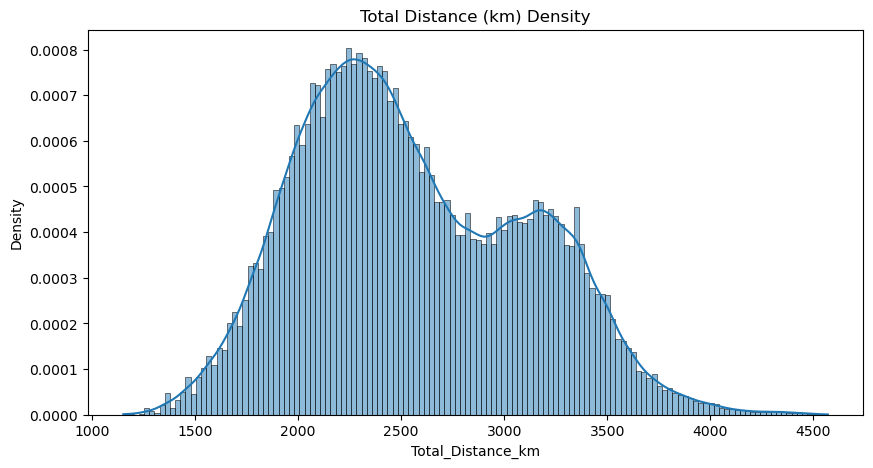

In [148]:
fig, ax = plt.subplots(figsize = (10, 5))

total_dist_df = final_data[["ID_Vehicle", "Total_Distance_km"]].drop_duplicates()

sns.histplot(data = total_dist_df, x = "Total_Distance_km", ax = ax, kde = True, stat = "density")

ax.set_title("Total Distance (km) Density")

plt.show()


The distribution of the Total logistic distance of each vehicle is bimodal. The majority of vehicles has a total logistic distance of roughly `2,200`km. But there is also a peak in the distribution at around `3,250`km. For sustainablity purposes it could be targeted to reduce this peak and analyse the source of it. 

For this purpose it is usefull to compare the total distance accross each part and component of the vehicle. Additionally also the different route Stages are compared to identify high logistic costs.  

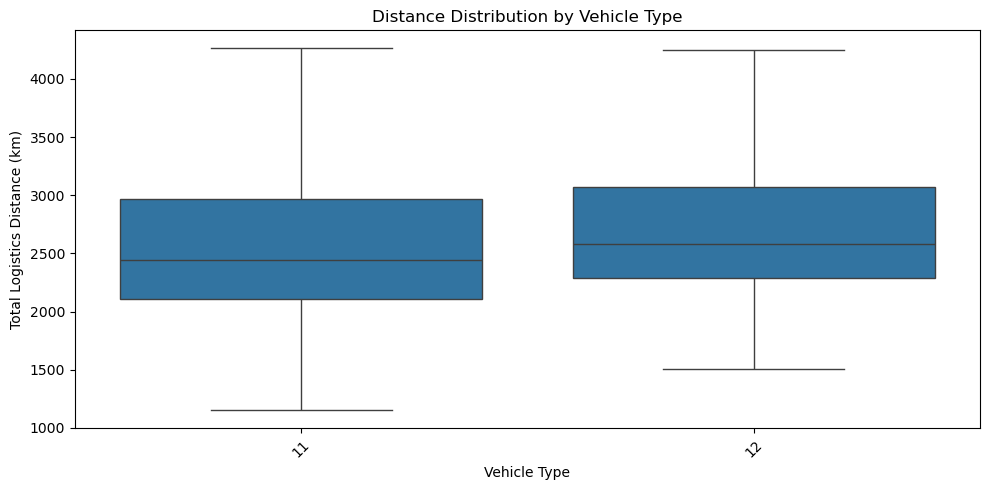

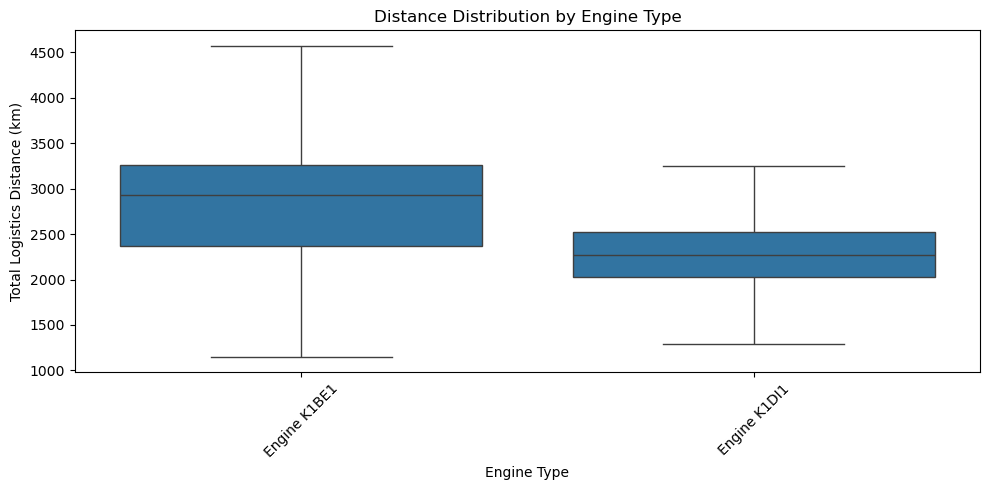

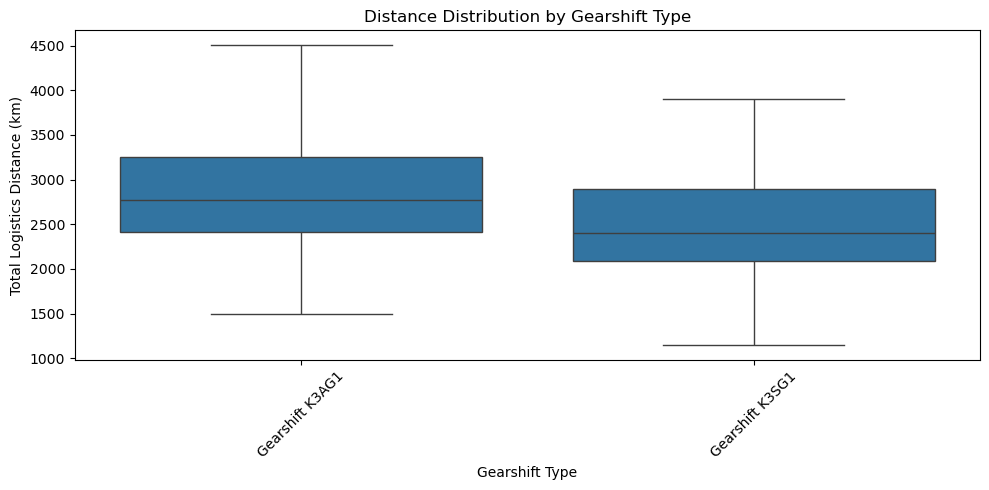

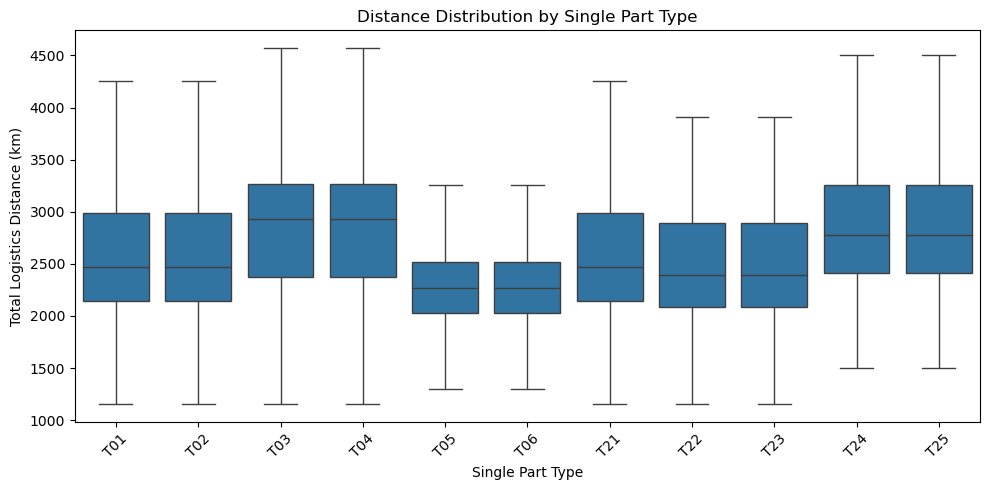

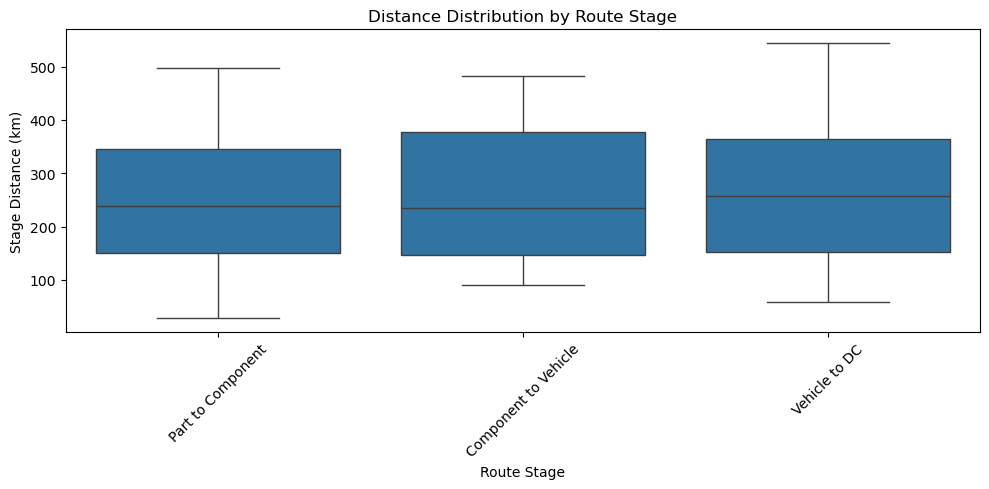

In [149]:
boxplot_data = {
    "Vehicle Type": (
        final_data[
            ["ID_Vehicle", "Vehicle_Type", "Total_Distance_km"]
        ]
        .drop_duplicates(),
        "Vehicle_Type",
        "Total_Distance_km"
    ),

    "Engine Type": (
        final_data[
            final_data["Type_Origin"].str.startswith("Engine", na=False)
        ][
            ["ID_Vehicle", "Type_Origin", "Total_Distance_km"]
        ]
        .drop_duplicates(),
        "Type_Origin",
        "Total_Distance_km"
    ),

    "Gearshift Type": (
        final_data[
            final_data["Type_Origin"].str.startswith("Gearshift", na=False)
        ][
            ["ID_Vehicle", "Type_Origin", "Total_Distance_km"]
        ]
        .drop_duplicates(),
        "Type_Origin",
        "Total_Distance_km"
    ),

    "Single Part Type": (
        final_data[
            final_data["Type_Origin"].str.startswith("T", na=False)
        ][
            ["ID_Vehicle", "Type_Origin", "Total_Distance_km"]
        ]
        .drop_duplicates(),
        "Type_Origin",
        "Total_Distance_km"
    ),

    "Route Stage": (
        final_data[
            ["Route_Stage", "Distance_km"]
        ],
        "Route_Stage",
        "Distance_km"
    )
}


for category, (data, x_col, y_col) in boxplot_data.items():

    data = data.copy()

    if isinstance(data[x_col].dtype, pd.CategoricalDtype):
        data[x_col] = data[x_col].cat.remove_unused_categories()

    fig, ax = plt.subplots(figsize=(10, 5))

    sns.boxplot(
        data=data,
        x=x_col,
        y=y_col,
        ax=ax,
        showfliers=False
    )

    ax.set_title(f"Distance Distribution by {category}")
    ax.set_xlabel(category)

    if category == "Route Stage":
        ax.set_ylabel("Stage Distance (km)")
    else:
        ax.set_ylabel("Total Logistics Distance (km)")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Interpretation: 

##### Vehicle Types: 
Vehicle `Type 11` shows a slightly lower median total logistics distance than Vehicle Type 12. Its quartiles are also shifted somewhat downward, indicating that Vehicle Type 11 generally requires shorter transportation distances across the supply chain. From the sustainability perspective, this suggests a small logistical advantage for Vehicle Type 11, since shorter transport distances are associated with lower transportation effort and potentially lower emissions. However, the distributions overlap considerably, so the difference between the two vehicle types is relatively moderate.

#### Engine Types: 
Engine `K1DI1` shows a clearly lower median total logistics distance than Engine K1BE1. The entire distribution is shifted toward shorter distances, and its spread is also smaller. From a sustainability perspective, vehicles equipped with Engine `K1DI1` therefore appear more favorable in terms of logistics, as their supply chains generally require less transportation distance. This suggests that the choice of engine type has a noticeable influence on the logistical sustainability of the vehicle.

#### Gearshift Types: 
Gearshift `K3SG1` shows a lower median total logistics distance than Gearshift K3AG1, and its distribution is generally shifted toward shorter distances. From a sustainability perspective, vehicles equipped with `K3SG1` therefore appear somewhat more favorable in terms of logistics, since their associated supply chains tend to require less transportation distance. However, the distributions still overlap considerably, so the difference is noticeable but not as pronounced as for the engine types.

#### Singe Part Types:
The single-part types show noticeable differences in their associated total logistics distances. In particular, T05 and T06 have comparatively low median distances, indicating shorter supply-chain transportation distances for vehicles containing these parts. In contrast, parts such as T03, T04, T24, and T25 are associated with higher total logistics distances. From a sustainability perspective, this suggests that the choice and sourcing of individual parts can influence the overall transportation effort of the vehicle supply chain.

#### Route Stages: 
The different route stages show only minor differences in their median logistics distances and overall spread. The distributions overlap strongly, indicating that no single route stage clearly dominates the total transportation effort. From a sustainability perspective, this suggests that optimization potential is distributed across all stages of the supply chain rather than being concentrated in one specific stage.

## 6.2 App Presentation

- the application can be run by `streamlit run .\SoSe26_Case_Study_App_Group_11.py` with all requirements from `requirements.txt` installed.
- the application only runs with the final dataset located under `data/SoSe26_Case_Study_finalData_Group_11.csv`
- The App is split into 4 main sections:
	- **Overview**: The objective of the analysis is explained and the user is guided through the app
	- **Route Explorer (Map)**: The logistics routes are visualised and can be explored interactively
	- **Distance Analysis (Boxplot)**: The main insights are presented in a clear and concise way
	- **Data Exploration**: The final dataset can be explored interactively and downloaded for further analysis

In the following some screenshots are added to demonstrate the app: 

## Overview
![general_overview](./additional_files/app_objective_overview.png)

## Route Explorer

The route explorer allows the user to select from a subset of example vehicles and input the Vehicle ID broken down into its semantic meaning of `Vehicle Type - Manufacturer - Plant - Vehicle Number` 

Each route stage is visualised and can be isolated by using the legend. Additionally each node contains relevant hover information such as Stage, Origin, Destination and Types.

![map1](./additional_files/app_map1.png)
![map2](./additional_files/app_map2.png)

## Distance Analysis

In the distance analysis tab the user can create interactive boxplots comparing several groups in the dataset. 

The grouping options include: 

- Vehicle Type

- Engine Type

- Gearshift Type

- Single Part Type

- Rout Stages


The Boxplots are kept in the standard version of displaying the median, the 25th and the 75th percentile. The whiskers represent the outlier threshholds of +- 1,5*IQR to the respective quantile.  


![boxplot](./additional_files/app_boxplot.png)

## Dataset Overview

In this tab a paginated overview of the final dataset is provided. The user can specify the number of rows shown in each page and the page currently presented.

![data_overview](./additional_files/app_dataset_overview.png)